# Lotka-Volterra

The Lotka–Volterra model is a simple mathematical model used to describe predator–prey interactions. It represents the system at the population level, describing how the numbers of prey and predators change over time. The model captures a simple cycle: when prey numbers increase, predators have more food and their population grows; as predator numbers increase, prey numbers decline; with fewer prey available, the predator population then declines, allowing the prey population to recover. This produces repeating population cycles and provides a simple way to explore how changes in birth, death, and predation rates affect the dynamics of the system.

## Exploratory Data Analysis

This section will analyse a predator-prey dataset. This is the classic 1847–1903 snowshoe hare and Canadian lynx fur pelt dataset from the Hudson's Bay Company (Leigh, 1968).

We will first load the data.

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from caliagent.models import simulate_lotka_volterra

infile = Path("data") / "leigh_1968_hare_lynx.csv"
df = pd.read_csv(infile)
df.head(10)

,year,hare,lynx
0,1847,21000,49000
1,1848,12000,21000
2,1849,24000,9000
3,1850,50000,7000
4,1851,80000,5000
5,1852,80000,5000
6,1853,90000,11000
7,1854,69000,22000
8,1855,80000,33000
9,1856,93000,33000


Let's look at the population of predators and prey over time. 

Let's also use our imagination and pretend that hares are sheep and that wolves are lynxes - we will later compare the Lotka-Volterra model to the Wolf and Sheep Predation model. We can also rescale the population counts so that we don't have to simulate such a large number of agents later on.

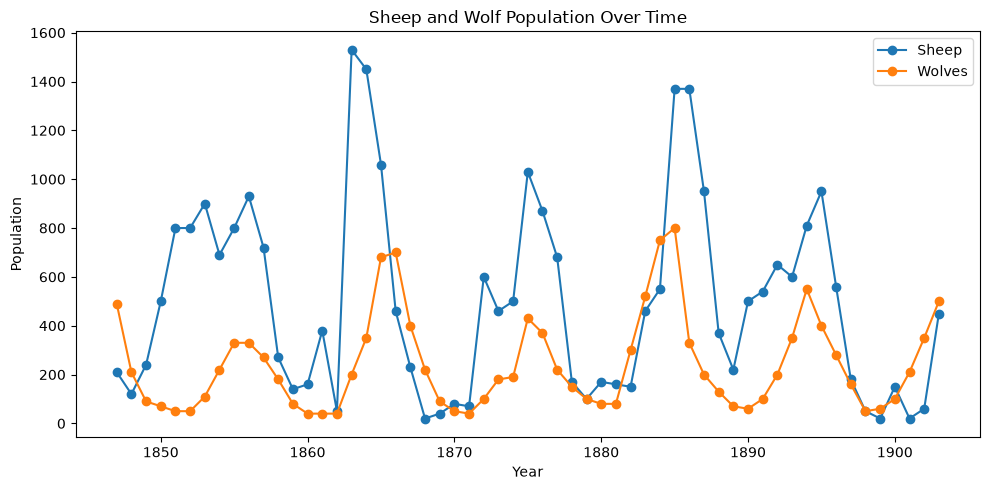

In [2]:
df["sheep"] = df["hare"] /  100
df["wolf"] = df["lynx"] /  100

plt.figure(figsize=(10, 5))
plt.plot(df["year"], df["sheep"], marker="o", label="Sheep")
plt.plot(df["year"], df["wolf"], marker="o", label="Wolves")
plt.xlabel("Year")
plt.ylabel("Population")
plt.title("Sheep and Wolf Population Over Time")
plt.legend()
plt.tight_layout()
plt.show()

## Running the Model

We can now use the Lotka–Volterra model to generate a simulated predator–prey time series. The model describes the changes in wolf and sheep populations over time using four parameters that control sheep reproduction, predation, wolf mortality, and wolf growth. We start with an initial population of sheep and wolves and use the model to simulate their dynamics over the same time period as our observations. This gives us a set of simulated populations that we can compare with the observed data.

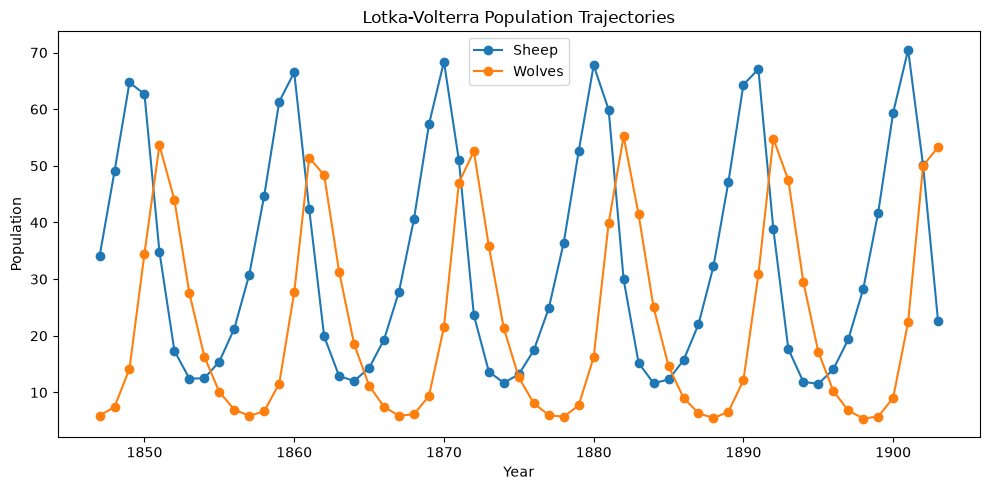

In [3]:
simulated = simulate_lotka_volterra(years=df.year.values)

plt.figure(figsize=(10, 5))
plt.plot(simulated["year"], simulated["sheep"], marker="o", label="Sheep")
plt.plot(simulated["year"], simulated["wolf"], marker="o", label="Wolves")
plt.xlabel("Year")
plt.ylabel("Population")
plt.title("Lotka-Volterra Population Trajectories")
plt.legend()
plt.tight_layout()
plt.show()

The model produces clear cycles in the wolf and sheep populations, with increases in sheep followed by increases in wolves, which then cause the sheep population to decline. As the number of sheep falls, the wolf population also decreases, allowing the sheep population to recover and the cycle to begin again. Although the model captures the general pattern of predator–prey dynamics, the simulated populations do not perfectly match the observed data. This highlights an important question: how should we choose the model parameters so that the simulated behaviour better matches what we observe?

## References

- Leigh, E. (1968). The ecological role of Volterra's equations. Some mathematical problems in biology., 1-61.